In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [47]:
def getCSV(csv):
    dfl = pd.read_csv(csv)
    return dfl
df = getCSV(r"C:\Users\Tom\OneDrive\Documents\APROJECTS\TradeCountries.csv")
print(list(set(df['Countries and Territories'])))

['Ukraine', "Cote d'Ivoire", 'Northern Mariana Islands', 'Albania', 'France', 'Sri Lanka', 'Unknown (Non-EU)', 'Gibraltar', 'Uganda', 'Bangladesh', 'Kyrgyzstan', 'Tajikistan', 'Guyana', 'Mali', 'Tanzania, United Republic of', 'Bonaire, Sint Eustatius and Saba', 'Switzerland', 'Morocco', 'Stores and Provisions (Non EU)', 'St Lucia', 'Spain', 'Sint Maarten (Dutch part)', 'Venezuela, Bolivarian republic of', 'Moldova, Republic of', 'Christmas Island', 'Andorra', 'Oman', 'Mauritius', 'St Pierre and Miquelon', 'Wallis and Futuna', 'Bahrain', 'Bosnia and Herzegovina', 'Costa Rica', 'Myanmar', 'Cocos Islands(or Keeling Islands)', 'Pitcairn', 'Kosovo', 'Haiti', 'Honduras', 'Senegal', 'Chad', 'Lesotho', 'Nepal', 'Sudan', 'Samoa', 'Guinea-Bissau', 'Western Sahara', 'Bulgaria', 'New Zealand', 'Eritrea', 'Armenia', 'Anguilla', 'Antigua and Barbuda', 'Belize', 'Nicaragua', 'Central African Republic', 'Chile', 'Sierra Leone', 'Indonesia', 'Northern Ireland', 'Ethiopia', 'South Africa', 'Comoros', 'S

In [112]:
country = "China"
label = "Value of Exports"
filtered_df = df[df['Year']==2024]
filtered_df = filtered_df[filtered_df['Countries and Territories']==country] 
filtered_df = filtered_df[filtered_df['Statistic Label']==label]
filtered_df['Commodity Group'] = filtered_df['Commodity Group'].apply(lambda x: x[:-5])
filtered_df = filtered_df.dropna()
filtered_top_ten_df = filtered_df.nlargest(10, 'VALUE')
print(filtered_top_ten_df)
print(list(set(filtered_top_ten_df['Commodity Group'])))

        Statistic Label  Year Countries and Territories  \
51012  Value of Exports  2024                     China   
50991  Value of Exports  2024                     China   
51022  Value of Exports  2024                     China   
51014  Value of Exports  2024                     China   
50988  Value of Exports  2024                     China   
50969  Value of Exports  2024                     China   
51020  Value of Exports  2024                     China   
50961  Value of Exports  2024                     China   
51021  Value of Exports  2024                     China   
50962  Value of Exports  2024                     China   

                                         Commodity Group           UNIT  \
51012      Electrical machinery, appliances etc., n.e.s.  Euro Thousand   
50991              Medicinal and pharmaceutical products  Euro Thousand   
51022        Miscellaneous manufactured articles, n.e.s.  Euro Thousand   
51014                          Other transport equ

In [113]:
def changeNames(name):
    switch = {
        "Telecommunications and sound recording, reproducing equipment": "Telecommunications and sound \nrecording, reproducing equipment",
        "Essential oils, perfume materials, toilet preparations etc.": "Essential oils, perfume materials, \ntoilet preparations etc.",
        "Office machines and automatic data processing equipment": "Office machines and automatic \ndata processing equipment",
        "Photographic apparatus, optical goods, watches and clocks": "Photographic apparatus, optical \ngoods, watches and clocks",
        "Paper, paperboard and articles of paper pulp, paper etc.": "Paper, paperboard and articles \nof paper pulp, paper etc.",
        
    }
    if name in switch:
        return switch[name]
    else: 
        return name
filtered_top_ten_df['Commodity Group'] = filtered_top_ten_df['Commodity Group'].apply(changeNames)

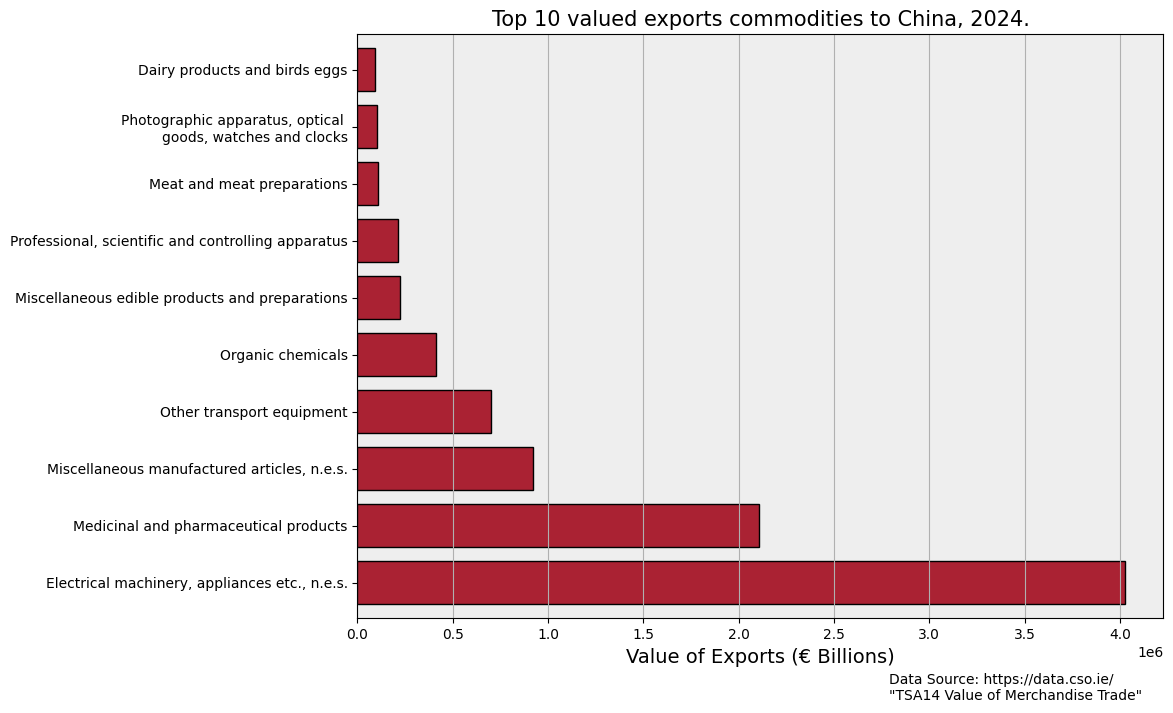

In [114]:
fig, ax = plt.subplots(1, 1, figsize=(13, 8))

filtered_top_ten_df.plot(x="Commodity Group", y="VALUE", kind="barh", width=0.75, edgecolor="black", color="#A23", ax=ax)

title_string = 'Top 10 valued exports commodities to '+country+", 2024."

plt.title(title_string, fontsize=15)
plt.xlabel(label+" (€ Billions)", fontsize=14)
plt.ylabel('', fontsize=14)
plt.xticks(rotation=0) 
#ax.set_xlim(200,550)
ax.set_facecolor('#EEEEEE') 
#ax.legend(percentage_df['Towns'].tolist(), percentage_df['VALUE'].tolist())
ax.get_legend().remove()
plt.grid(True, axis="x")

plt.subplots_adjust(left=0.3, right=0.92, top=0.9, bottom=0.17)
plt.text(0.66, -0.14, "Data Source: https://data.cso.ie/ \n\"TSA14 Value of Merchandise Trade\"", ha='left', transform=ax.transAxes)

save_fig = label+"-"+country+'.png'
plt.savefig(save_fig)

# Show the plot
plt.show()


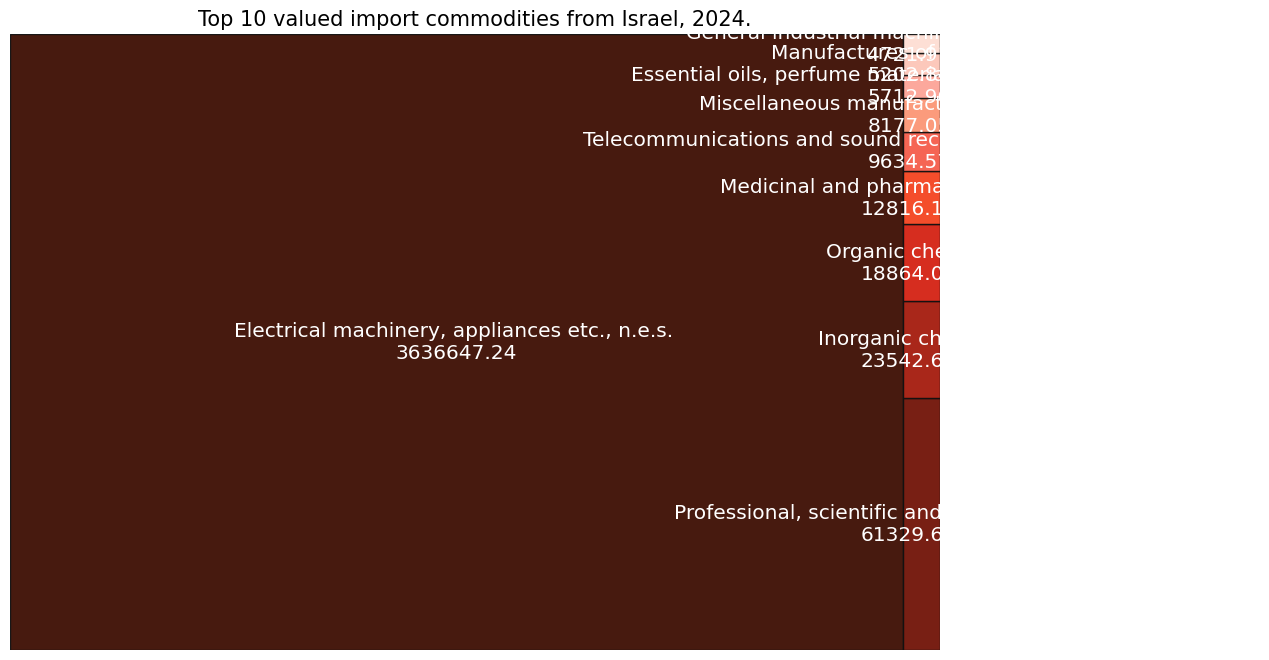

In [26]:
import squarify

fig, ax = plt.subplots(1,1,figsize=(12,8))

#color_scale =['#10273d','#1F4E79','#2E5E91','#3D6DA9','#4C7CC1','#5B8BDA','#6A9AF2','#79AAFB','#88BAFF','#99CCFF']
color_scale = ['#3d0d02', '#711307', '#a51b0d', '#d42113', '#f4431f', '#f55d4b', '#fb9675', '#fca397', '#fcc5b8', '#fdded3']

labels = [f"{commodity+' '}\n"+f"{str(val)}" for commodity,val in zip(filtered_top_ten_df['Commodity Group'].tolist(), filtered_top_ten_df['VALUE'].tolist())] 


squarify.plot(sizes=filtered_top_ten_df['VALUE'], label=labels, alpha=0.95, ec='#111111', color=color_scale, pad=0.0, text_kwargs = {'fontsize': 14.5, 'color': 'white'})
plt.axis('off')  # Remove axis
plt.title('Top 10 valued import commodities from '+country+', 2024.', fontsize=15)  # Add title if needed

plt.savefig(label+"-"+country+'-square.png')

plt.show()